# Multinomial Logistic Regression (Softmax Classifier)

In [1]:
# Step 1: Import the libraries needed
import os  # To read files and folders
import numpy as np  # To work with numbers and arrays
import pandas as pd  # To display tables and summaries
import matplotlib.pyplot as plt  # To draw charts and plots
import seaborn as sns  # To make confusion matrix look clear
from PIL import Image  # To open preprocessed images

# Import tools from scikit-learn
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score


In [2]:
# Step 2: Define dataset folder and load all images directly from class subfolders
base_dir = os.path.join("..", "results", "outputs")
if not os.path.exists(base_dir):
    base_dir = os.path.join("results", "outputs")

# Find all 7 class folders
classes = sorted([d for d in os.listdir(base_dir) if os.path.isdir(os.path.join(base_dir, d))])
print("Found classes in dataset:")
for index, class_name in enumerate(classes):
    print(f"  Class {index}: {class_name}")

X_images = []
y_labels = []

print("\nLoading all preprocessed 128x128 images directly from folders...")
for class_index, class_name in enumerate(classes):
    folder_path = os.path.join(base_dir, class_name)
    all_files = os.listdir(folder_path)
    
    # Load all images in the folder
    for filename in all_files:
        if filename.lower().endswith(('.jpg', '.jpeg', '.png')):
            img_path = os.path.join(folder_path, filename)
            # Open 128x128 image and convert to grayscale
            img = Image.open(img_path).convert('L')
            # Turn image pixels into numbers between 0 and 1
            pixels = np.array(img, dtype=np.float32).flatten() / 255.0
            X_images.append(pixels)
            y_labels.append(class_index)
            
    print(f"  Loaded {len(all_files)} images from: {class_name}")

X = np.array(X_images)
y = np.array(y_labels)
print(f"\nTotal loaded images: {len(y)}")
print(f"Each image has {X.shape[1]} pixels (128x128 = 16384)")


Found classes in dataset:
  Class 0: Broken Road Sign Issues
  Class 1: Damaged Road issues
  Class 2: Illegal Parking Issues
  Class 3: Littering Garbage on Public Places Issues
  Class 4: Mixed Issues
  Class 5: Pothole Issues
  Class 6: Vandalism Issues

Loading all preprocessed 128x128 images directly from folders...


  Loaded 3331 images from: Broken Road Sign Issues


  Loaded 3331 images from: Damaged Road issues


  Loaded 3331 images from: Illegal Parking Issues


  Loaded 3331 images from: Littering Garbage on Public Places Issues


  Loaded 3331 images from: Mixed Issues


  Loaded 3331 images from: Pothole Issues


  Loaded 3331 images from: Vandalism Issues

Total loaded images: 23317
Each image has 16384 pixels (128x128 = 16384)


In [3]:
# Step 3: Split into 80% training data and 20% testing data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples:  {len(X_test)}")

# Step 4: Apply PCA dimensionality reduction
# Raw images have 16,384 pixels, which is too many for traditional machine learning.
# PCA finds the 50 most important patterns that describe the image.
pca = PCA(n_components=50, random_state=42)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

variance = np.sum(pca.explained_variance_ratio_) * 100
print(f"PCA complete! 50 components explain {variance:.2f}% of the image information.")


Training samples: 18653
Testing samples:  4664


PCA complete! 50 components explain 79.92% of the image information.


In [4]:
# Step 5: Train a baseline Logistic Regression model
# C is the regularization parameter (default is 1.0)
baseline_model = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
baseline_model.fit(X_train_pca, y_train)

# Check accuracy on training data and test data
train_pred = baseline_model.predict(X_train_pca)
test_pred = baseline_model.predict(X_test_pca)

train_acc = accuracy_score(y_train, train_pred) * 100
test_acc = accuracy_score(y_test, test_pred) * 100

print("Baseline Logistic Regression:")
print(f"Training Accuracy: {train_acc:.2f}%")
print(f"Testing Accuracy:  {test_acc:.2f}%")


Baseline Logistic Regression:
Training Accuracy: 40.56%
Testing Accuracy:  38.92%


Testing different C values:


  When C = 0.01  -> Train Accuracy: 40.60%, Test Accuracy: 38.72%


  When C = 0.1   -> Train Accuracy: 40.56%, Test Accuracy: 38.92%


  When C = 1.0   -> Train Accuracy: 40.56%, Test Accuracy: 38.92%


  When C = 10.0  -> Train Accuracy: 40.59%, Test Accuracy: 38.89%


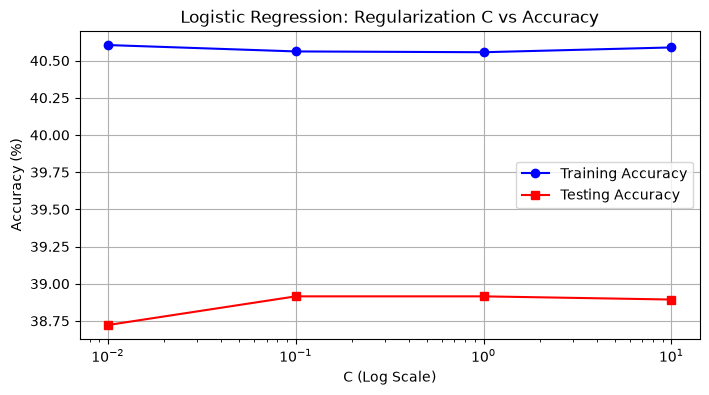

In [5]:
# Step 6: Hyperparameter tuning - Test different values of C
# C controls how strictly the model fits the training data
# Smaller C = simpler model, Bigger C = more complex model
c_choices = [0.01, 0.1, 1.0, 10.0]
train_scores = []
test_scores = []

print("Testing different C values:")
for c in c_choices:
    clf = LogisticRegression(C=c, max_iter=1000, random_state=42)
    clf.fit(X_train_pca, y_train)
    
    tr = accuracy_score(y_train, clf.predict(X_train_pca)) * 100
    te = accuracy_score(y_test, clf.predict(X_test_pca)) * 100
    
    train_scores.append(tr)
    test_scores.append(te)
    print(f"  When C = {c:<5} -> Train Accuracy: {tr:.2f}%, Test Accuracy: {te:.2f}%")

# Plot the tuning curve to show the effect of C
plt.figure(figsize=(8, 4))
plt.plot(c_choices, train_scores, 'o-', label='Training Accuracy', color='blue')
plt.plot(c_choices, test_scores, 's-', label='Testing Accuracy', color='red')
plt.xscale('log')
plt.title('Logistic Regression: Regularization C vs Accuracy')
plt.xlabel('C (Log Scale)')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)
plt.show()


In [6]:
# Step 7: 5-Fold Cross Validation
# Split training data into 5 parts and test 5 times to check stability
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = cross_val_score(baseline_model, X_train_pca, y_train, cv=cv, scoring='accuracy')

print("5-Fold Cross Validation Scores:")
for fold_number, score in enumerate(cv_results, 1):
    print(f"  Fold {fold_number}: {score * 100:.2f}%")
print(f"Average CV Accuracy: {cv_results.mean() * 100:.2f}%")


5-Fold Cross Validation Scores:
  Fold 1: 40.87%
  Fold 2: 40.20%
  Fold 3: 39.21%
  Fold 4: 39.09%
  Fold 5: 38.90%
Average CV Accuracy: 39.66%


Classification Report:
                 precision    recall  f1-score   support

Broken Road Sig       0.34      0.29      0.31       666
Damaged Road is       0.31      0.36      0.33       666
Illegal Parking       0.51      0.58      0.54       666
Littering Garba       0.41      0.45      0.43       667
   Mixed Issues       0.39      0.46      0.42       666
 Pothole Issues       0.41      0.26      0.32       666
Vandalism Issue       0.35      0.33      0.34       667

       accuracy                           0.39      4664
      macro avg       0.39      0.39      0.38      4664
   weighted avg       0.39      0.39      0.38      4664



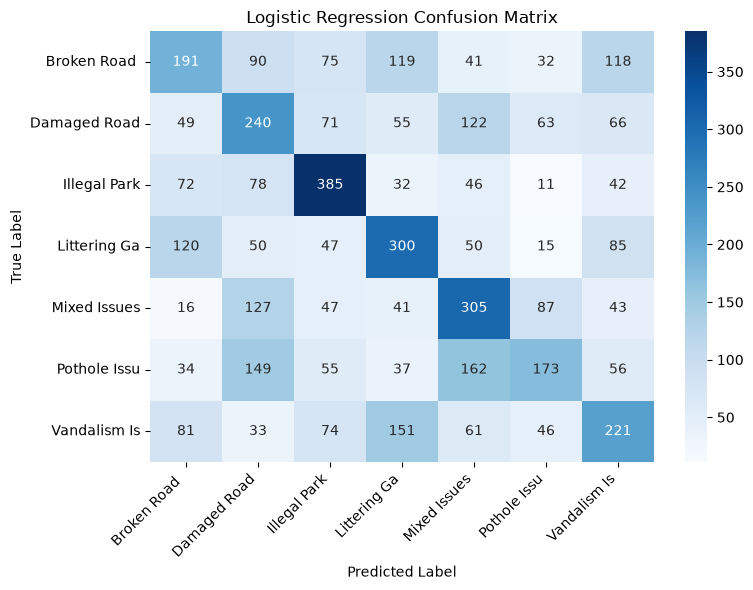

In [7]:
# Step 8: Final Model Evaluation and Confusion Matrix
final_predictions = baseline_model.predict(X_test_pca)

print("Classification Report:")
print(classification_report(y_test, final_predictions, target_names=[c[:15] for c in classes]))

# Plot confusion matrix
cm = confusion_matrix(y_test, final_predictions)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[c[:12] for c in classes], yticklabels=[c[:12] for c in classes])
plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [8]:
# Step 9: Overfitting and Underfitting Summary
# Compare training accuracy against testing accuracy
overfitting_gap = train_acc - test_acc
print("--- Overfitting Analysis ---")
print(f"Training Accuracy:  {train_acc:.2f}%")
print(f"Testing Accuracy:   {test_acc:.2f}%")
print(f"Overfitting Gap:    {overfitting_gap:.2f}%")

if overfitting_gap < 5:
    print("Observation: The overfitting gap is very small (less than 5%).")
    print("Reason: Logistic Regression has high bias (it is a linear model), so it does not overfit.")
    print("However, because images have complex curves and textures, a linear decision boundary cannot separate them well (underfitting).")
else:
    print("Observation: The model shows some gap between training and testing.")


--- Overfitting Analysis ---
Training Accuracy:  40.56%
Testing Accuracy:   38.92%
Overfitting Gap:    1.64%
Observation: The overfitting gap is very small (less than 5%).
Reason: Logistic Regression has high bias (it is a linear model), so it does not overfit.
However, because images have complex curves and textures, a linear decision boundary cannot separate them well (underfitting).
